In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn import metrics
from sklearn import tree
import warnings

In [2]:
df_crop = pd.read_csv('../../dataset/crop_recommendation_dataset.csv')

In [3]:
df_crop.head()

,temperature,humidity,rainfall,ph,nitrogen,phosphorous,potassium,carbon,soil,label
0,20.879744,82.002744,202.935536,6.502985,69.30,79.50000,94.4400,0.63,Loamy Soil,rice
1,21.770462,80.319644,226.655537,7.038096,72.02,141.82400,141.6978,1.40,Loamy Soil,rice
2,23.004459,82.320763,263.964248,7.633568,77.77,59.39000,81.8900,1.80,Peaty Soil,rice
3,26.491096,80.283629,242.864034,6.980401,78.65,147.45895,142.9430,1.43,Loamy Soil,rice
4,20.280071,81.604873,262.717340,7.628473,73.98,68.95000,95.7400,1.75,Peaty Soil,rice


In [4]:
df_crop.tail()

,temperature,humidity,rainfall,ph,nitrogen,phosphorous,potassium,carbon,soil,label
3095,25.287846,89.636679,58.286977,6.765095,57.3400,144.48000,73.08,1.64,Neutral Soil,watermelon
3096,26.638386,84.695469,48.324286,6.189214,56.0600,61.34000,47.95,1.35,Peaty Soil,watermelon
3097,25.331045,84.305338,41.532187,6.904242,54.9395,145.53795,97.83,1.58,Neutral Soil,watermelon
3098,26.820601,83.892415,43.971937,6.463271,55.5100,76.89000,50.92,0.68,Acidic Soil,watermelon
3099,26.820601,89.413849,58.548767,6.260839,57.6525,66.29000,50.56,1.49,Acidic Soil,watermelon


In [5]:
df_crop.shape

(3100, 10)

In [6]:
df_crop.columns

Index(['temperature', 'humidity', 'rainfall', 'ph', 'nitrogen', 'phosphorous',
       'potassium', 'carbon', 'soil', 'label'],
      dtype='object')

In [7]:
df_crop['label'].unique()

array(['rice', 'wheat', 'Mung Bean', 'Tea', 'millet', 'maize', 'Lentil',
       'Jute', 'Coffee', 'Cotton', 'Ground Nut', 'Peas', 'Rubber',
       'Sugarcane', 'Tobacco', 'Kidney Beans', 'Moth Beans', 'Coconut',
       'Black gram', 'Adzuki Beans', 'Pigeon Peas', 'Chickpea', 'banana',
       'grapes', 'apple', 'mango', 'muskmelon', 'orange', 'papaya',
       'pomegranate', 'watermelon'], dtype=object)

In [8]:
crop_mapping = {
    'rice': 'padi',
    'wheat': 'gandum',
    'Mung Bean': 'kacang hijau',
    'Tea': 'teh',
    'millet': 'jagung mutiara',
    'maize': 'jagung',
    'Lentil': 'kacang lentil',
    'Jute': 'rami',
    'Coffee': 'kopi',
    'Cotton': 'kapas',
    'Ground Nut': 'kacang tanah',
    'Peas': 'kacang polong',
    'Rubber': 'karet',
    'Sugarcane': 'tebu',
    'Tobacco': 'tembakau',
    'Kidney Beans': 'kacang merah',
    'Moth Beans': 'kacang ngengat',
    'Coconut': 'kelapa',
    'Black gram': 'kacang hitam',
    'Adzuki Beans': 'kacang adzuki',
    'Pigeon Peas': 'kacang gude',
    'Chickpea': 'kacang arab',
    'banana': 'pisang',
    'grapes': 'anggur',
    'apple': 'apel',
    'mango': 'mangga',
    'muskmelon': 'blewah',
    'orange': 'jeruk',
    'papaya': 'pepaya',
    'pomegranate': 'delima',
    'watermelon': 'semangka'
}
df_crop['label'] = df_crop['label'].replace(crop_mapping)

In [ ]:
# df_crop['label'] = df_crop['label'].replace('rice', 'padi')
# df_crop['label'] = df_crop['label'].replace('maize', 'jagung')
# df_crop['label'] = df_crop['label'].replace('chickpea', 'kacang arab')
# df_crop['label'] = df_crop['label'].replace('kidneybeans', 'kacang merah')
# df_crop['label'] = df_crop['label'].replace('pigeonpeas', 'kacang gude')
# df_crop['label'] = df_crop['label'].replace('mothbeans', 'kacang ngengat')
# df_crop['label'] = df_crop['label'].replace('mungbean', 'kacang hijau')
# df_crop['label'] = df_crop['label'].replace('blackgram', 'kacang hitam')
# df_crop['label'] = df_crop['label'].replace('lentil', 'kacang lentil')
# df_crop['label'] = df_crop['label'].replace('pomegranate', 'delima')
# df_crop['label'] = df_crop['label'].replace('banana', 'pisang')
# df_crop['label'] = df_crop['label'].replace('mango', 'mangga')
# df_crop['label'] = df_crop['label'].replace('grapes', 'anggur')
# df_crop['label'] = df_crop['label'].replace('watermelon', 'semangka')
# df_crop['label'] = df_crop['label'].replace('muskmelon', 'blewah')
# df_crop['label'] = df_crop['label'].replace('apple', 'apel')
# df_crop['label'] = df_crop['label'].replace('orange', 'jeruk')
# df_crop['label'] = df_crop['label'].replace('papaya', 'pepaya')
# df_crop['label'] = df_crop['label'].replace('coconut', 'kelapa')
# df_crop['label'] = df_crop['label'].replace('cotton', 'kapas')
# df_crop['label'] = df_crop['label'].replace('jute', 'rami')
# df_crop['label'] = df_crop['label'].replace('coffee', 'kopi')


In [9]:
df_crop.dtypes

temperature    float64
humidity       float64
rainfall       float64
ph             float64
nitrogen       float64
phosphorous    float64
potassium      float64
carbon         float64
soil            object
label           object
dtype: object

C:\Users\ferdy\AppData\Local\Temp\ipykernel_25032\1379104656.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df_crop.corr(),annot=True)


<Axes: >

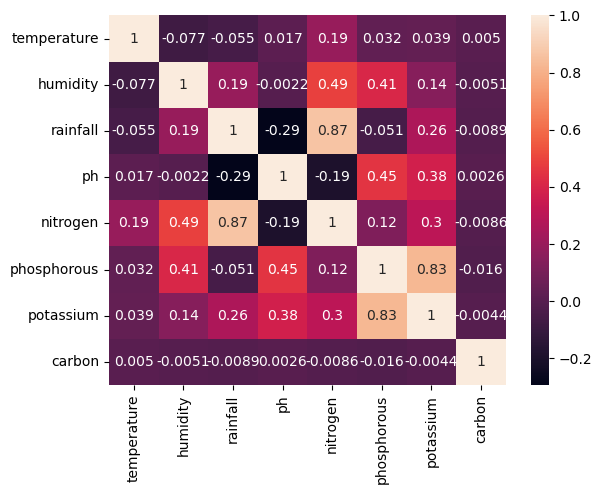

In [10]:
sns.heatmap(df_crop.corr(),annot=True)

In [11]:
features = df_crop[['temperature', 'humidity', 'rainfall']]
target = df_crop['label']
labels = df_crop['label']

In [12]:
acc = []
model = []

In [13]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, Ytrain, Ytest = train_test_split(features,target,test_size = 0.2,random_state=2)

In [14]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score

NaiveBayes = GaussianNB()

NaiveBayes.fit(Xtrain,Ytrain)

predicted_values = NaiveBayes.predict(Xtest)
x = metrics.accuracy_score(Ytest, predicted_values)
acc.append(x)
model.append('Naive Bayes')

print(classification_report(Ytest,predicted_values))

                precision    recall  f1-score   support

        anggur       0.77      1.00      0.87        17
          apel       0.68      0.76      0.72        17
        blewah       1.00      1.00      1.00        20
        delima       0.71      0.68      0.70        22
        gandum       0.71      0.68      0.70        22
        jagung       0.78      0.78      0.78        23
jagung mutiara       1.00      1.00      1.00        13
         jeruk       0.88      0.88      0.88        25
 kacang adzuki       1.00      1.00      1.00        19
   kacang arab       0.95      0.95      0.95        22
   kacang gude       1.00      0.70      0.82        23
  kacang hijau       1.00      1.00      1.00        20
  kacang hitam       0.79      0.90      0.84        21
 kacang lentil       0.86      1.00      0.93        19
  kacang merah       0.94      0.94      0.94        17
kacang ngengat       1.00      0.74      0.85        23
 kacang polong       1.00      1.00      1.00  

In [15]:
score = cross_val_score(NaiveBayes,features,target,cv=5)
score

array([0.89032258, 0.87419355, 0.86935484, 0.85      , 0.88870968])

In [16]:
import pickle
Model_pkl_filename = '../../model/ModelClassifier.pkl'
Model_pkl = open(Model_pkl_filename, 'wb')
pickle.dump(NaiveBayes, Model_pkl)
Model_pkl.close()

In [17]:
data = df_crop
data['label'].unique()

data['min_range_temperature'] = 0
data['max_range_temperature'] = 0
data['min_range_humidity'] = 0
data['max_range_humidity'] = 0
data['min_range_rainfall'] = 0
data['max_range_rainfall'] = 0

for i in data['label'].unique():
    data.loc[data['label'] == i, 'min_range_temperature'] = data[data['label'] == i]['temperature'].min()
    data.loc[data['label'] == i, 'max_range_temperature'] = data[data['label'] == i]['temperature'].max()
    data.loc[data['label'] == i, 'min_range_humidity'] = data[data['label'] == i]['humidity'].min()
    data.loc[data['label'] == i, 'max_range_humidity'] = data[data['label'] == i]['humidity'].max()
    data.loc[data['label'] == i, 'min_range_rainfall'] = data[data['label'] == i]['rainfall'].min()
    data.loc[data['label'] == i, 'max_range_rainfall'] = data[data['label'] == i]['rainfall'].max()
    
data = data.drop_duplicates(subset='label')

data = data[['label', 'min_range_temperature', 'max_range_temperature', 'min_range_humidity', 'max_range_humidity', 'min_range_rainfall', 'max_range_rainfall']]

In [18]:
data.to_csv('../../dataset/crop_recommendation_range.csv', index=False)